# Lecture du texte de référeence

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
with open('data/bible.txt','r',encoding='utf-8') as f:
    text = f.read()
print('Longueur du texte en nombre de caractères :', len(text))
print(text[:1000])

Longueur du texte en nombre de caractères : 3334225
LA 

SAINTE  BIBLE 

COMMENTÉE 


TOME   I 


DU  MÊME  AUTEUR 


INTRODUCTION  GÉNÉRALE  AUX  ÉVANGILES.  Un  vol.  grand  in-S"  de  1 

ÉVANGILE    SELON    SAINT    MATTHIEU.    INTRODUCTION  CRITIQUE  ET  COMW 
grand  in -80  de  570  p.  Paris,  1878. 

ÉVANGILE  SELON    SAINT   MARC.    INTRODUCTION  CRITIQUE  ET  COMMENTAII 

in -80  de  228  p.  Paris,  1879. 

ÉVANGILE  SELON   SAINT   LUC.    INTRODUCTION  CRITIQUE  ET   COMMENTAIRI 

in -8°  de  415  p.  Paris,  1882. 

ÉVANGILE  SELON   SAINT  JEAN.    INTRODUCTION  CRITIQUE  ET  COMMENTAI! 

in-80  de  Lxiv-388  p.  Paris,  1886. 

SYNOPSIS   EVANGELICA,  SEU  QUATUOR  SANCTA  JeSU   ChRISTI   EvANGELI. 
GATAM  EDITIONEM  ORDINE  CHRONOLOGICO  IN  HARMONIAM  CONCINNATA.  l 

de  xix-138  p.  Paris,  1882. 

ESSAIS    D'EXÉGÈSE.    EXPOSITION,   RÉFUTATION,   CRITIQUE,  MŒURS  JUIVES, 

de  XI -35 4  p.  Lyon,  1884. 

ATLAS  ARCHÉOLOGIQUE  DE  LA   BIBLE,  d'apriîS  LES

# Construction du vocabulaire

In [119]:
#nettoyage du texte
import re
def preprocess_text(_text):
    """Nettoie un fichier texte pour l'entraînement NLP"""
        
    # Stats avant nettoyage
    original_length = len(_text)
    original_lines = _text.count('\n')
    
    # Nettoyage
    _text = re.sub(r'[ \t]+', ' ', _text)              # Espaces multiples
    _text = re.sub(r'\n{3,}', '\n\n', _text)           # Lignes vides
    _text = re.sub(r'(?m)^[ \t]+|[ \t]+$', '', _text)  # Espaces début/fin ligne
    _text = re.sub(r'\s+([.,;:!?])', r'\1', _text)     # Espace avant ponctuation
    _text = _text.strip()

    # 1. Remplacements intelligents
    _text = _text.replace('—', '-')
    _text = _text.replace('«', '"').replace('»', '"')
    _text = _text.replace('[', '(').replace(']', ')')
    _text = _text.replace('{', '(').replace('}', ')')
    _text = _text.replace(''', "'").replace(''', "'")
    _text = _text.replace('…', '...')
    _text = _text.replace('«', '"').replace('»', '"')
    
    # 2. Filtrer caractères
    allowed = set(
        'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'
        '0123456789 .,;:!?\'\"-\n'
        'àâçèéêëîïôùûÀÂÇÉÈÊËÎÏÔÙÛœŒ'
        '()'
    )
    _text = ''.join(c for c in _text if c in allowed)
    
    # 3. Normaliser espaces
    _text = re.sub(r' +', ' ', _text)
    _text = re.sub(r'\n{3,}', '\n\n', _text)
    _text = re.sub(r'(?m)^[ ]+|[ ]+$', '', _text)
    
    print(f"Texte nettoyé: {len(_text):,} caractères")
    
    _text = _text.strip()    
    # Stats après nettoyage
    cleaned_length = len(_text)
    cleaned_lines = _text.count('\n')
    
    print(f"Nettoyage terminé:")
    print(f"  Caractères: {original_length:,} → {cleaned_length:,} ({cleaned_length/original_length*100:.1f}%)")
    print(f"  Lignes: {original_lines:,} → {cleaned_lines:,}")
    
    return _text

In [120]:
text_ = preprocess_text(text)
print(text_[:1000])

Texte nettoyé: 2,828,664 caractères
Nettoyage terminé:
  Caractères: 3,334,225 → 2,828,664 (84.8%)
  Lignes: 98,704 → 93,285
LA

SAINTE BIBLE

COMMENTÉE

TOME I

DU MÊME AUTEUR

INTRODUCTION GÉNÉRALE AUX ÉVANGILES. Un vol. grand in-S" de 1

ÉVANGILE SELON SAINT MATTHIEU. INTRODUCTION CRITIQUE ET COMW
grand in -80 de 570 p. Paris, 1878.

ÉVANGILE SELON SAINT MARC. INTRODUCTION CRITIQUE ET COMMENTAII

in -80 de 228 p. Paris, 1879.

ÉVANGILE SELON SAINT LUC. INTRODUCTION CRITIQUE ET COMMENTAIRI

in -8 de 415 p. Paris, 1882.

ÉVANGILE SELON SAINT JEAN. INTRODUCTION CRITIQUE ET COMMENTAI!

in-80 de Lxiv-388 p. Paris, 1886.

SYNOPSIS EVANGELICA, SEU QUATUOR SANCTA JeSU ChRISTI EvANGELI.
GATAM EDITIONEM ORDINE CHRONOLOGICO IN HARMONIAM CONCINNATA. l

de xix-138 p. Paris, 1882.

ESSAIS D'EXÉGÈSE. EXPOSITION, RÉFUTATION, CRITIQUE, MŒURS JUIVES,

de XI -35 4 p. Lyon, 1884.

ATLAS ARCHÉOLOGIQUE DE LA BIBLE, d'apriîS LES MEILLEURS DOCUME
SOIT MODERNES, ET SURTOUT d'aPRÈS LES DÉCOUVERTES LES PLUS R

In [121]:
# get all unique characters in the text
chars = sorted(list(set(text_)))
vocab_size = len(chars)
print('Nombre de caractères uniques :', vocab_size)
print('Liste des caractères uniques :', ''.join(chars))

Nombre de caractères uniques : 101
Liste des caractères uniques : 
 !"'(),-.0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyzÀÂÇÈÉÊËÎÏÔÙÛàâçèéêëîïôùûŒœ


In [17]:
# create mapping from characters to integers and vice versa
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] 
decode = lambda l: ''.join([itos[i] for i in l])  

print(encode("bonjour le Monde"))
print(decode(encode("bonjour le Monde")))

[64, 77, 76, 72, 77, 83, 80, 1, 74, 67, 1, 44, 77, 76, 66, 67]
bonjour le Monde


In [18]:
# convert entire text to a tensor of integers
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) 

torch.Size([3334225]) torch.int64
tensor([ 43,  32,   1,   0,   0,  50,  32,  40,  45,  51,  36,   1,   1,  33,
         40,  33,  43,  36,   1,   0,   0,  34,  46,  44,  44,  36,  45,  51,
        106,  36,   1,   0,   0,   0,  51,  46,  44,  36,   1,   1,   1,  40,
          1,   0,   0,   0,  35,  52,   1,   1,  44, 107,  44,  36,   1,   1,
         32,  52,  51,  36,  52,  49,   1,   0,   0,   0,  40,  45,  51,  49,
         46,  35,  52,  34,  51,  40,  46,  45,   1,   1,  38, 106,  45, 106,
         49,  32,  43,  36,   1,   1,  32,  52,  55,   1,   1, 106,  53,  32,
         45,  38,  40,  43,  36,  50,  14,   1,   1,  52,  76,   1,   1,  84,
         77,  74,  14,   1,   1,  69,  80,  63,  76,  66,   1,   1,  71,  76,
         13,  50,   3,   1,   1,  66,  67,   1,   1,  17,   1,   0,   0, 106,
         53,  32,  45,  38,  40,  43,  36,   1,   1,   1,   1,  50,  36,  43,
         46,  45,   1,   1,   1,   1,  50,  32,  40,  45,  51,   1,   1,   1,
          1,  44,  32,  51,  5

In [19]:
# separate into train and validation sets
n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]
print(train_data.shape, val_data.shape)

torch.Size([3000802]) torch.Size([333423])


# Les fonctions

In [50]:
torch.manual_seed(1965)
block_size = 8  # context length
batch_size = 4 # how many independent sequences will we process in parallel?
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))  # batch size 32
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb)
print('targets:')
print(yb)
print('----')
for b in range(4):  # show 4 examples
    for t in range(block_size):
        context = xb[b,:t+1]
        target = yb[b,t]
        print(f'when input is {context.tolist()} the target: {target.item()}')
    print('----')

inputs:
tensor([[ 82,   1,   1,  65,  77,  83,  80,  82],
        [118,  64,  80,  67,  83,   1,   1,  26],
        [ 81,  67,   1,   0,  65,  63,  65,  70],
        [ 66,  67,   1,   1,  74,   7,  70,  83]])
targets:
tensor([[ 1,  1, 65, 77, 83, 80, 82,  1],
        [64, 80, 67, 83,  1,  1, 26,  1],
        [67,  1,  0, 65, 63, 65, 70, 63],
        [67,  1,  1, 74,  7, 70, 83, 71]])
----
when input is [82] the target: 1
when input is [82, 1] the target: 1
when input is [82, 1, 1] the target: 65
when input is [82, 1, 1, 65] the target: 77
when input is [82, 1, 1, 65, 77] the target: 83
when input is [82, 1, 1, 65, 77, 83] the target: 80
when input is [82, 1, 1, 65, 77, 83, 80] the target: 82
when input is [82, 1, 1, 65, 77, 83, 80, 82] the target: 1
----
when input is [118] the target: 64
when input is [118, 64] the target: 80
when input is [118, 64, 80] the target: 67
when input is [118, 64, 80, 67] the target: 83
when input is [118, 64, 80, 67, 83] the target: 1
when input is [118, 6

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1965)

class BigramLanguageModeler(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)  # (B,T,C)
    
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T) # targets shape (-1)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        # idx is (B,T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, _ = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :]  # becomes (B,C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1)  # (B,C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (B,1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1)  # (B,T+1)
        return idx
    

In [52]:
m = BigramLanguageModeler(vocab_size)
logits, loss = m(xb, yb)
print('logits shape:', logits.shape)
print('loss:', loss)
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(m.generate(idx, max_new_tokens=100)[0].tolist()))

logits shape: torch.Size([32, 135])
loss: tensor(5.2183, grad_fn=<NllLossBackward0>)

ÊSn~•h£cÛèLC$;RFQ%7ÏuXâyig8HŒp—•Xâ„Œ?t£lÈ4cŒ«vgY¥xvèf\g)AÇdÏ2\x—ZÉ5™T&gû=^)XADéikQ_3»X6.Bnpëfœ.a■g 4


In [53]:
# create the optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3) #or SGD optimizer

In [54]:
batch_size = 32
for steps in range(10000):
    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if steps % 1000 == 0:
        print(steps, loss.item())

0 5.208894729614258
1000 4.124216079711914
2000 3.381028652191162
3000 2.8797104358673096
4000 2.819525718688965
5000 2.727041721343994
6000 2.5385427474975586
7000 2.5041067600250244
8000 2.384328603744507
9000 2.5312068462371826


In [55]:
idx = torch.zeros((1, 1), dtype=torch.long)
print(decode(m.generate(idx, max_new_tokens=300)[0].tolist()))


dibapun denalin    
ph-115Flab me       pat TO^:  ÇDottrurertrarica    — 
Coues  le Que   —FChom  LUphoin  Is  t et 

tr sare 1. i aitind prez ©+^Ç}À]Obe  
spr  ce   sitrur.   ,    
5. presi- qu'a lesa   q,  


sign-ple enerqGaces t  ttesis   dusiniolllos cif.    ùËxà   ientmout,  te  —    donappava


# Mathematiques de la self Attention

In [48]:
torch.manual_seed(1965)
B, T, C = 4, 8, 2 # batch size, time steps, channels
x = torch.randn(B, T, C)
print(x.shape)

torch.Size([4, 8, 2])


In [65]:
# Exemple de multiplication matricielle avec une matrice de masque triangulaire inférieure
torch.manual_seed(1965)
a = torch.tril(torch.ones(3,3))
a = a / torch.sum(a,dim=1,keepdim=True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=',a)
print('----')
print('b=',b)
print('----')
print('c=',c)

a= tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
----
b= tensor([[9., 0.],
        [7., 5.],
        [2., 2.]])
----
c= tensor([[9.0000, 0.0000],
        [8.0000, 2.5000],
        [6.0000, 2.3333]])


In [49]:
xbow = torch.zeros(B, T, C)
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1]  # (t, C)
        xbow[b, t] = torch.mean(xprev, dim=0)
print(xbow.shape)
# xbow est la moyenne des vecteurs de caractéristiques depuis le début jusqu'au temps t pour chaque batch b de x

torch.Size([4, 8, 2])


In [72]:
# Exemple de multiplication matricielle avec une matrice de masque triangulaire inférieure pour obtenir la moyenne cumulative
# de manière plus efficace
#
weight = torch.tril(torch.ones(T,T))
weight = weight / torch.sum(weight, dim=1, keepdim=True)
xbow2 = weight @ x  # (B,T,T) @ (B,T,C) -> (B,T,C)

print('Matrice identique ? ',torch.allclose(xbow, xbow2))
print('weight =\n',weight)
print(xbow2.shape)


Matrice identique ?  True
weight =
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])
torch.Size([4, 8, 2])


In [ ]:
# best practice
tril = torch.tril(torch.ones(T,T)).unsqueeze(0)  # (1,T,T) matrice de masque triangulaire inférieure
weight = torch.zeros((T,T))
weight = weight.masked_fill(tril == 0, float('-inf')) # mask upper triangular part with -inf (for softmax)
weight = F.softmax(weight, dim=-1) # normalized weights
xbow3 = weight @ x  # (B,T,T) @ (B,T,C) -> (B,T,C)
print('Matrice identique ? ',torch.allclose(xbow, xbow3))
print(xbow3.shape)

Matrice identique ?  True
torch.Size([4, 8, 2])


In [74]:
tril

tensor([[[1., 0., 0., 0., 0., 0., 0., 0.],
         [1., 1., 0., 0., 0., 0., 0., 0.],
         [1., 1., 1., 0., 0., 0., 0., 0.],
         [1., 1., 1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 1., 1., 0., 0., 0.],
         [1., 1., 1., 1., 1., 1., 0., 0.],
         [1., 1., 1., 1., 1., 1., 1., 0.],
         [1., 1., 1., 1., 1., 1., 1., 1.]]])

# Self-Attention

In [88]:
torch.manual_seed(1965)
B, T, C = 4, 8, 32 # batch size, time steps, channels
x = torch.randn(B, T, C)
# attention mechanism QKV
head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)
k = key(x)   # (B,T,head_size)
q = query(x) # (B,T,head_size)
weights = q @ k.transpose(-2,-1) * head_size**-0.5  # (B,T,head_size) @ (B,head_size,T) -> (B,T,T)

tril = torch.tril(torch.ones(T,T)).unsqueeze(0)  # (1,T,T) matrice de masque triangulaire inférieure
weights = weights.masked_fill(tril == 0, float('-inf')) # mask upper triangular part with -inf (for softmax)
weights = F.softmax(weights, dim=-1) # normalized weights 

v =value(x)  # (B,T,head_size)
out = weights @ v  # (B,T,T) @ (B,T,head_size) -> (B,T,head_size)

print(out.shape)

torch.Size([4, 8, 16])


In [87]:
weights[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6256, 0.3744, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4248, 0.2434, 0.3318, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1716, 0.3515, 0.2643, 0.2126, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2855, 0.1749, 0.2001, 0.1249, 0.2146, 0.0000, 0.0000, 0.0000],
        [0.2571, 0.1482, 0.1328, 0.1289, 0.1656, 0.1674, 0.0000, 0.0000],
        [0.1851, 0.1274, 0.1509, 0.1250, 0.1093, 0.1715, 0.1308, 0.0000],
        [0.0604, 0.0975, 0.1597, 0.1904, 0.1060, 0.1802, 0.0952, 0.1105]],
       grad_fn=<SelectBackward0>)

# Recharge le model sauvegardé

In [130]:
#---------------------------------------------------------------
# Hyperparameters

class Head(nn.Module):
    """One head of self-attention"""
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * C**-0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        out = wei @ v
        return out

class MultiHeadAttention(nn.Module):
    """Multiple heads of self-attention in parallel"""
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

class FeedForward(nn.Module):
    """A simple linear layer followed by a non-linearity"""
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    """Transformer block: communication followed by computation"""
    def __init__(self, n_embd, num_heads):
        super().__init__()
        head_size = n_embd // num_heads
        self.sa = MultiHeadAttention(num_heads, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class BigramLanguageModeler(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.positional_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, num_heads) for _ in range(n_layers)])
        self.ln_final = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.positional_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_final(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx
    
# Charger le checkpoint
#checkpoint = torch.load('bigram_full_model.pth', weights_only=False)
checkpoint = torch.load('bigram_french_model.pth', weights_only=False)

# Recréer le modèle
vocab_size = checkpoint['vocab_size']
stoi = checkpoint['stoi']
itos = checkpoint['itos']
n_embd = checkpoint.get('n_embd', 384)
num_heads = checkpoint.get('num_heads', 6)
n_layers = checkpoint.get('n_layers', 4)
block_size = checkpoint.get('block_size', 128)
dropout = checkpoint.get('dropout', 0.2)
decode = lambda l: ''.join([itos[i] for i in l])
# Extraire l'historique
train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
steps_recorded = checkpoint['steps_recorded']

model = BigramLanguageModeler(vocab_size)
model.load_state_dict(checkpoint['model_state_dict'])

# Configurer le device
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
model.eval()  # Important : mode évaluation

BigramLanguageModeler(
  (token_embedding_table): Embedding(100, 384)
  (positional_embedding_table): Embedding(256, 384)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x Head(
            (key): Linear(in_features=384, out_features=64, bias=False)
            (query): Linear(in_features=384, out_features=64, bias=False)
            (value): Linear(in_features=384, out_features=64, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((384,), eps=1e-05, elementwis

# Tracer les courbes d'apprentissage

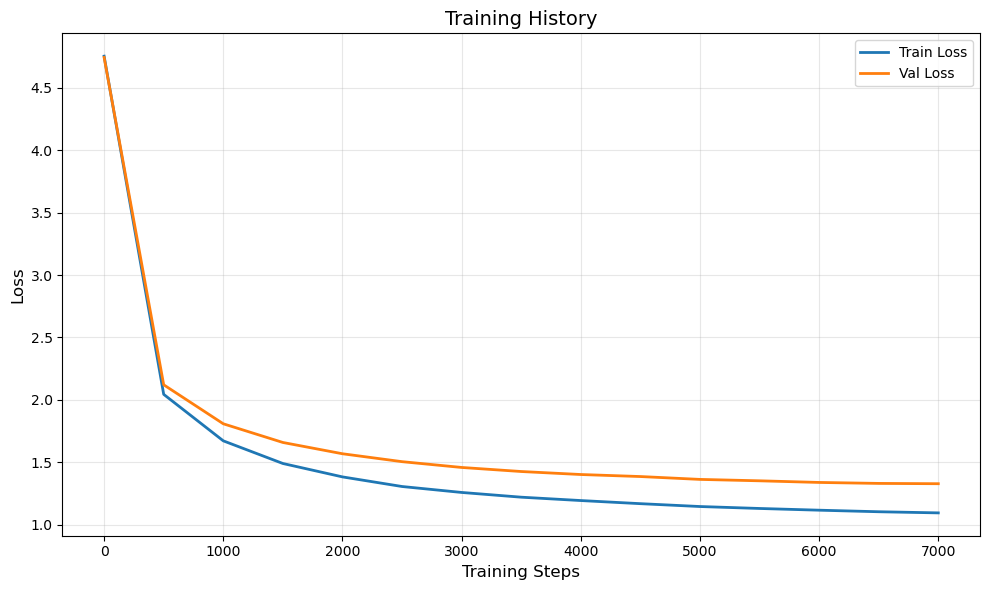

Final train loss: 1.0939
Final val loss: 1.3277
Best val loss: 1.3277 at step 6999


In [131]:
import matplotlib.pyplot as plt

# Tracer l'historique des pertes

plt.figure(figsize=(10, 6))
plt.plot(steps_recorded, train_losses, label='Train Loss', linewidth=2)
plt.plot(steps_recorded, val_losses, label='Val Loss', linewidth=2)
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training History', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")
print(f"Best val loss: {min(val_losses):.4f} at step {steps_recorded[val_losses.index(min(val_losses))]}")

# Générer du Texte ...

In [132]:
# Générer du texte
with torch.no_grad():
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated = model.generate(context, max_new_tokens=2000)
    print(decode(generated[0].tolist()))


la rue n'avait pas en criant l'amour en revint d'homme un noir, l'année
et Danglars; tout protégé d'une maîtresse monde, l'affecturité venait
qu'elle fut autour de l'espace, qui égal d'un meuble; et son diamant, il
s'arrêta aux hasards cinq chassants de Phileas Fogg, le cardinal à
Javert. En aidant, elle les avait opportée de son visage, une grande
bonne âme.

Par hasard un de soleil, à la mère de Cécile, elle revint de ses droits, de
larmes, le dessein encore et la rentrait. C'était une houille aux réflaires
où Maheu était étonné, les mineurs, les autres conscient, elle faisait
le nez mis de flutter; et il éprouvait fait, les jeunes genoux enseignaient
sous la tête, il se laissait donné sans un des secondes, disait sur un tel
rival.

--Y a-t-il eu votre esprit? demanda Cochepaille.

--Les belles femmes, reprit le brandissant, qu'il ne tourmentent.

Dès lors, lorsque les sciences, le titrent ravisés au pied de la vaste,
au côté de ses oreilles; et, soufflant en bouteille, très-oeuvres

In [127]:
print("=== Architecture du modèle ===")
print(model)

print("\n=== Nombre de paramètres ===")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total: {total_params:,} paramètres")
print(f"En millions: {total_params/1e6:.2f}M")

# Détail par type de couche
print("\n=== Détail par composant ===")
for name, param in model.named_parameters():
    print(f"{name:60s} {param.numel():>10,}  shape: {list(param.shape)}")

=== Architecture du modèle ===
BigramLanguageModeler(
  (token_embedding_table): Embedding(101, 384)
  (positional_embedding_table): Embedding(256, 384)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-5): 6 x Head(
            (key): Linear(in_features=384, out_features=64, bias=False)
            (query): Linear(in_features=384, out_features=64, bias=False)
            (value): Linear(in_features=384, out_features=64, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNor

In [133]:
def count_parameters(model):
    """Compte le nombre de paramètres dans le modèle"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"-*- Paramètres du modèle -*-")
    print(f"Total: {total_params:,}")
    print(f"Entraînables: {trainable_params:,}")
    print(f"Non-entraînables: {total_params - trainable_params:,}")
    
    # Conversion en millions
    print(f"\nEn millions: {total_params/1e6:.2f}M paramètres")
    
    return total_params

# Utilisation
total = count_parameters(model)

-*- Paramètres du modèle -*-
Total: 10,815,844
Entraînables: 10,815,844
Non-entraînables: 0

En millions: 10.82M paramètres
